In [1]:
# Importing  the pandas to read the dataset  
import pandas as pd

# Load your crop dataset
cy = pd.read_csv("crop_dataset.csv")
cy

,state,district,crop,crop_year,season,temperature,rainfall,area,production,yield
0,ANDAMAN AND NICOBAR ISLAND,NICOBARS,Arecanut,2007,Kharif,23.250000,1100.72570,2439.6,3415.0,1.40
1,ANDAMAN AND NICOBAR ISLAND,NICOBARS,Arecanut,2007,Rabi,23.250000,1100.72570,1626.4,2277.0,1.40
2,ANDAMAN AND NICOBAR ISLAND,NICOBARS,Arecanut,2008,Autumn,22.756923,405.56560,4147.0,3060.0,0.74
3,ANDAMAN AND NICOBAR ISLAND,NICOBARS,Arecanut,2008,Summer,22.756923,405.56560,4147.0,2660.0,0.64
4,ANDAMAN AND NICOBAR ISLAND,NICOBARS,Arecanut,2009,Autumn,23.503077,1060.89450,4153.0,3120.0,0.75
...,...,...,...,...,...,...,...,...,...,...
345322,WEST BENGAL,PURULIA,Wheat,2015,Rabi,23.865385,932.75670,855.0,1241.0,1.45
345323,WEST BENGAL,PURULIA,Wheat,2016,Rabi,24.496154,458.79095,1366.0,2415.0,1.77
345324,WEST BENGAL,PURULIA,Wheat,2017,Rabi,23.740000,1035.74290,1052.0,2145.0,2.04
345325,WEST BENGAL,PURULIA,Wheat,2018,Rabi,23.967692,2068.75515,833.0,2114.0,2.54


In [2]:
print(cy.shape)

(345327, 10)


In [3]:
# Converting  all column names to lowercase and remove extra spaces
cy.columns = cy.columns.str.strip().str.lower()

In [4]:
# Drop 'production' column since yield is the target variable
cy = cy.drop('production', axis=1)

In [5]:
cy.isnull().sum()

state          0
district       0
crop           0
crop_year      0
season         0
temperature    0
rainfall       0
area           0
yield          0
dtype: int64

In [6]:
# Counting  duplicate rows
duplicate_count = cy.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [ ]:
# 2. EXPLORATORY DATA ANALYSIS (EDA)

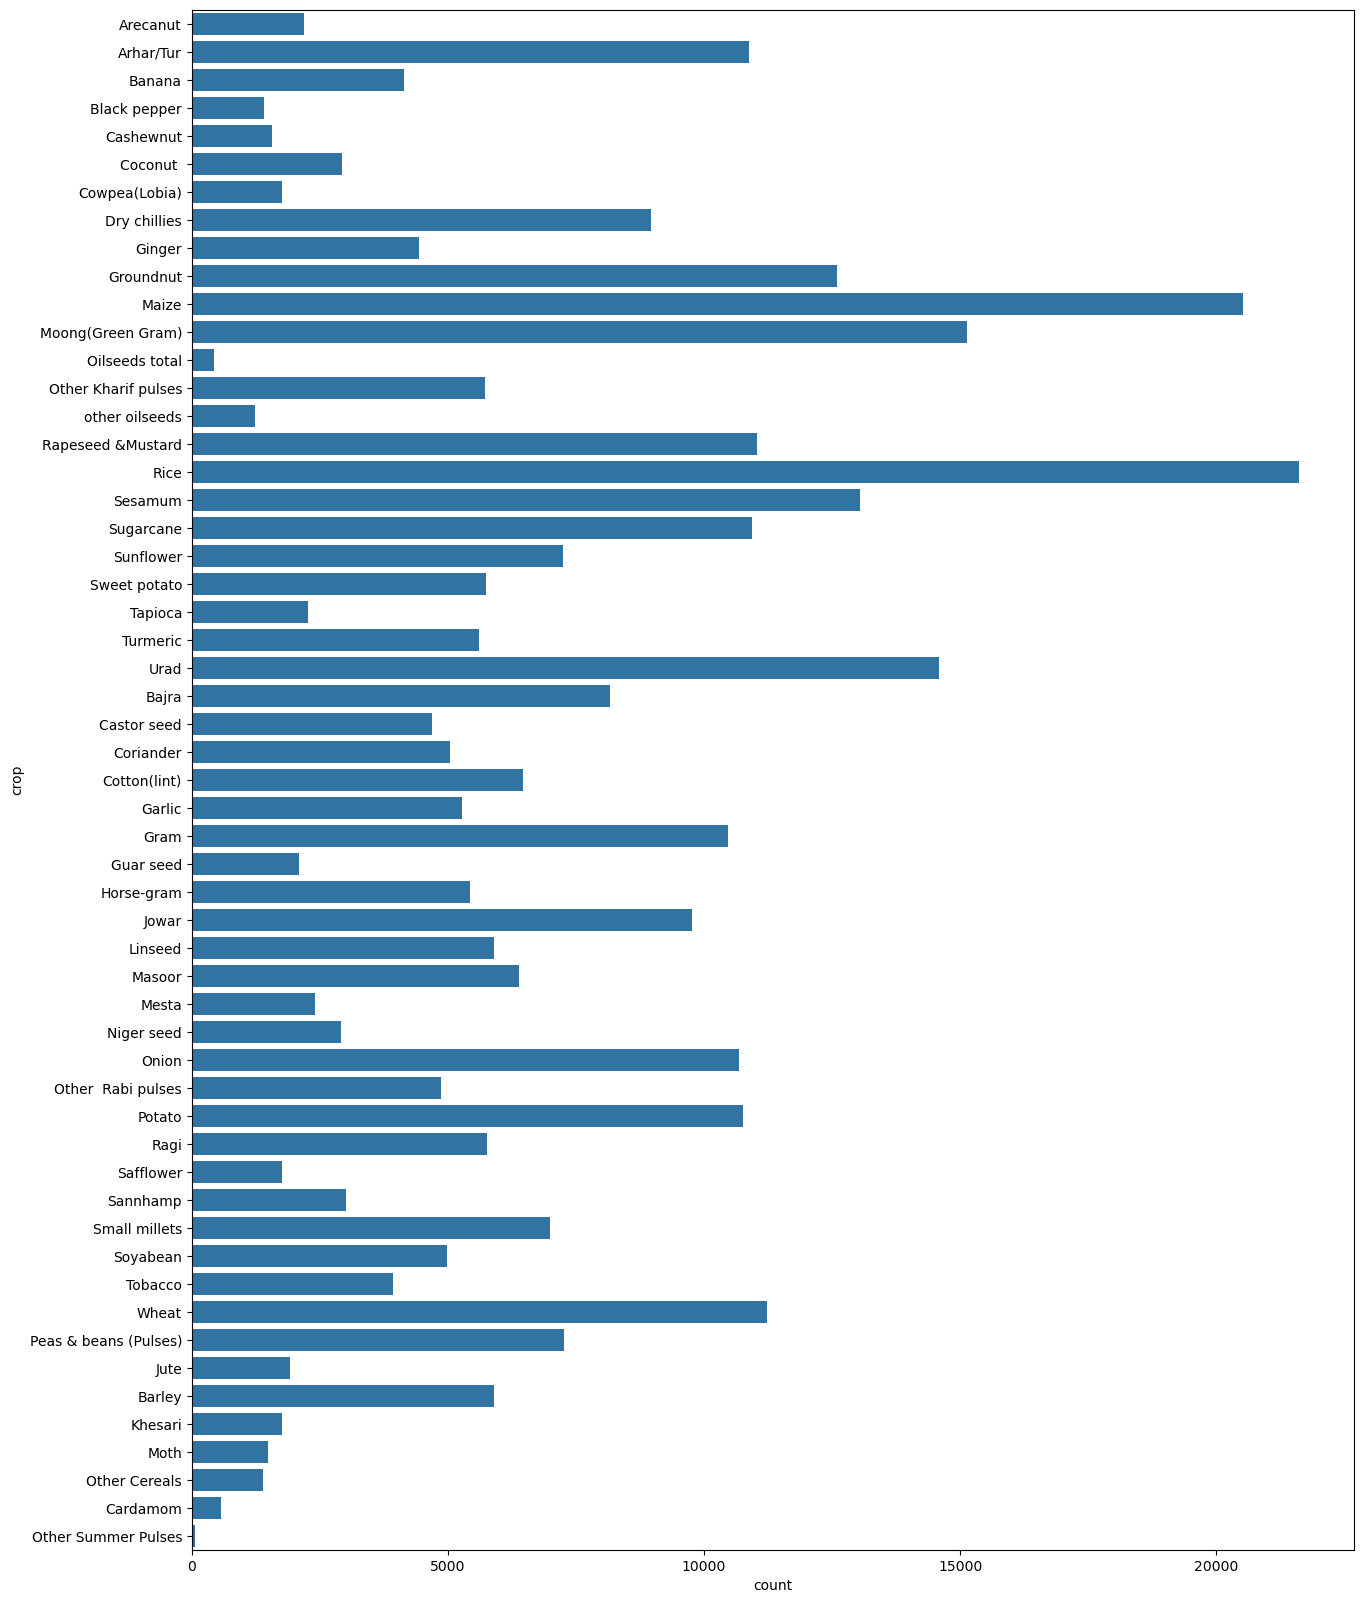

In [7]:
# Plot crop frequency distribution
import matplotlib.pyplot as plt 
import seaborn as sns 
plt.figure(figsize=(15,20))
sns.countplot(y = cy['crop'])
plt.show()

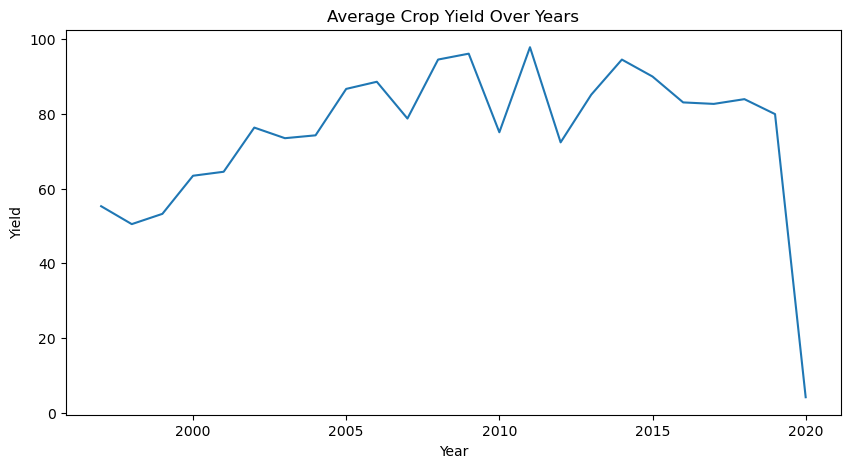

In [8]:
# Ploting average crop yield over years
import matplotlib.pyplot as plt

yield_year = cy.groupby('crop_year')['yield'].mean()

plt.figure(figsize=(10,5))
yield_year.plot()
plt.title('Average Crop Yield Over Years')
plt.xlabel('Year')
plt.ylabel('Yield')
plt.show()

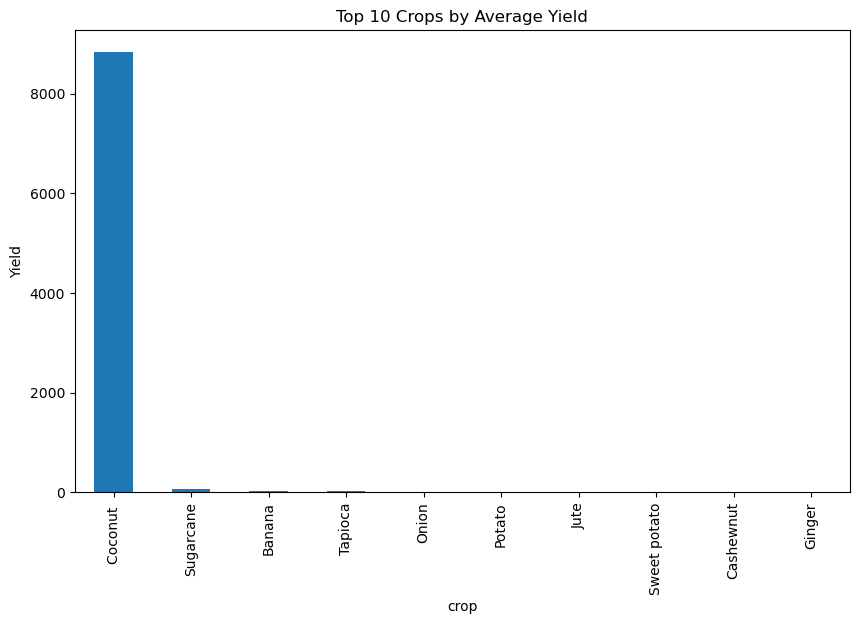

In [9]:
import seaborn as sns

top_crops = (
    cy.groupby('crop')['yield']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_crops.plot(kind='bar')
plt.title('Top 10 Crops by Average Yield')
plt.ylabel('Yield')
plt.show()

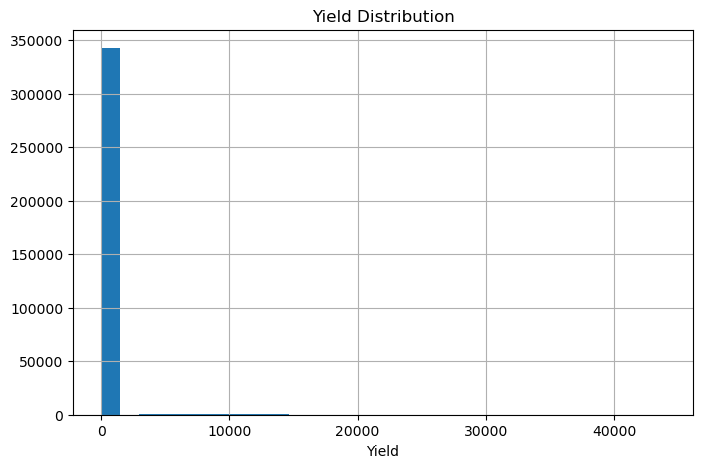

In [10]:
plt.figure(figsize=(8,5))
cy['yield'].hist(bins=30)
plt.title('Yield Distribution')
plt.xlabel('Yield')
plt.show()

In [11]:
# Remove extreme yield values using 2nd and 98th percentiles
lower = cy["yield"].quantile(0.02)
upper = cy["yield"].quantile(0.98)
cy = cy[(cy["yield"] >= lower) & (cy["yield"] <= upper)]

In [ ]:
4. FEATURE-TARGET SPLIT

In [12]:
X = cy.drop(['yield'], axis=1)
y = cy['yield']

In [ ]:
# 5. DATA PREPROCESSING

In [13]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# Numerical
num_cols = ['temperature', 'rainfall', 'area']

# Low-cardinality (good for OneHot)
low_cat = ['season', 'crop']

# High-cardinality (better with Ordinal)
high_cat = ['state', 'district']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('low_cat', OneHotEncoder(handle_unknown='ignore'), low_cat),
    ('high_cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), high_cat)
])

In [ ]:
# 6. TRAIN-TEST SPLIT

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# 7. APPLY PREPROCESSING

In [15]:
# Fit and transform training data
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)


In [ ]:
# 8. SAMPLE WEIGHTS

In [16]:
import numpy as np 
weights = 1 / np.sqrt(y_train + 1)

In [ ]:
# 9. MODEL TRAINING

In [18]:
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

# Sample weights
weights = 1 / np.sqrt(y_train + 1)

pipelines = {

    "Linear Regression": Pipeline([
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]),

    "Random Forest": Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=50,
            max_depth=15,
            min_samples_split=10,
            random_state=42
        ))
    ]),

    "Lasso": Pipeline([
        ('preprocessor', preprocessor),
        ('model', Lasso(alpha=0.001))
    ]),

    "Decision Tree": Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeRegressor(
            max_depth=10,
            random_state=42
        ))
     ])
}

results = []

for name, pipe in pipelines.items():

    # Models supporting sample weights
    if name in ["Linear Regression", "Random Forest", "Decision Tree", "XGBoost"]:
        pipe.fit(
            X_train,
            y_train,
            model__sample_weight=weights
        )
    else:
        pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "R2 Score": r2
    })

    print(f"{name} → MAE: {mae:.4f}, R²: {r2:.4f}")

# Results table
results_df = pd.DataFrame(results)

print("\nModel Comparison:")
print(results_df.sort_values("R2 Score", ascending=False))

Linear Regression → MAE: 1.7593, R²: 0.6711
Random Forest → MAE: 0.9710, R²: 0.9056
Lasso → MAE: 1.8311, R²: 0.7167
Decision Tree → MAE: 1.2738, R²: 0.8590

Model Comparison:
               Model       MAE  R2 Score
1      Random Forest  0.970957  0.905556
3      Decision Tree  1.273794  0.859002
2              Lasso  1.831081  0.716715
0  Linear Regression  1.759322  0.671081


In [19]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

# Sample weights
weights = 1 / np.sqrt(y_train + 1)

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=100,      # Reduced from 300
        max_depth=4,           # Reduced from 6
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',    # Faster training
        n_jobs=-1,             # Use all CPU cores
        random_state=42,
        objective='reg:squarederror'
    ))
])

# Train
xgb_pipeline.fit(
    X_train,
    y_train,
    model__sample_weight=weights
)

# Predict
y_pred = xgb_pipeline.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"XGBoost MAE: {mae:.4f}")
print(f"XGBoost R² Score: {r2:.4f}")

XGBoost MAE: 1.2774
XGBoost R² Score: 0.8414


In [ ]:
# 10. MODEL COMPARISON GRAPH

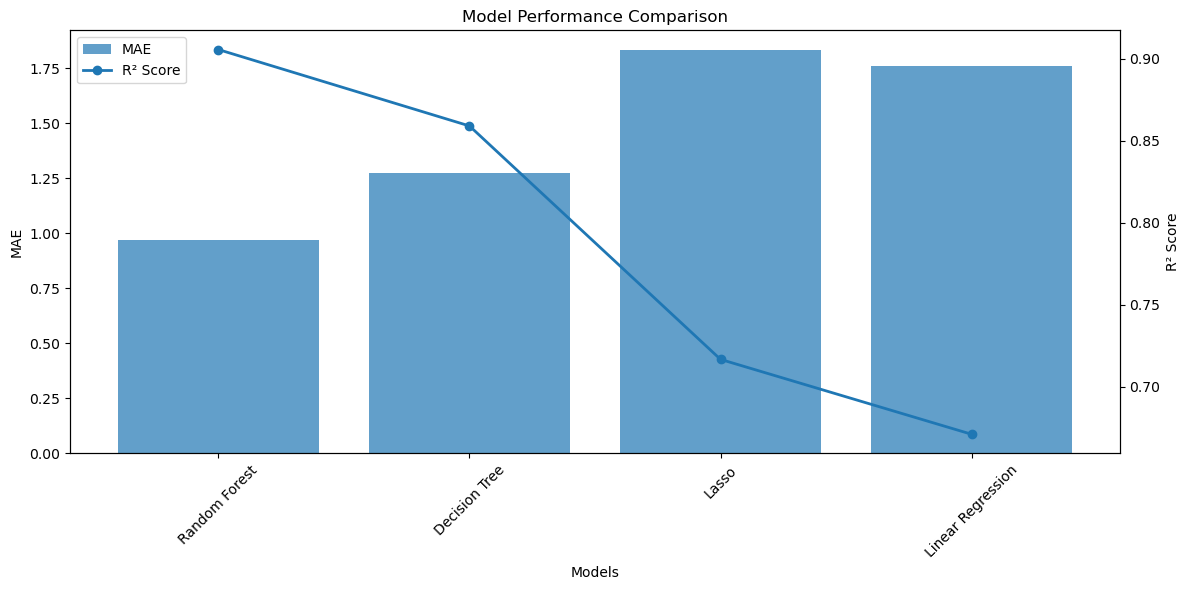

In [20]:
import matplotlib.pyplot as plt

# Sort by R² Score
results_df = results_df.sort_values("R2 Score", ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Left Y-axis for MAE
ax1.bar(
    results_df["Model"],
    results_df["MAE"],
    alpha=0.7,
    label="MAE"
)
ax1.set_xlabel("Models")
ax1.set_ylabel("MAE")
ax1.tick_params(axis='x', rotation=45)

# Right Y-axis for R²
ax2 = ax1.twinx()
ax2.plot(
    results_df["Model"],
    results_df["R2 Score"],
    marker='o',
    linewidth=2,
    label="R² Score"
)
ax2.set_ylabel("R² Score")

# Title
plt.title("Model Performance Comparison")

# Combined Legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="best")

plt.tight_layout()
plt.show()

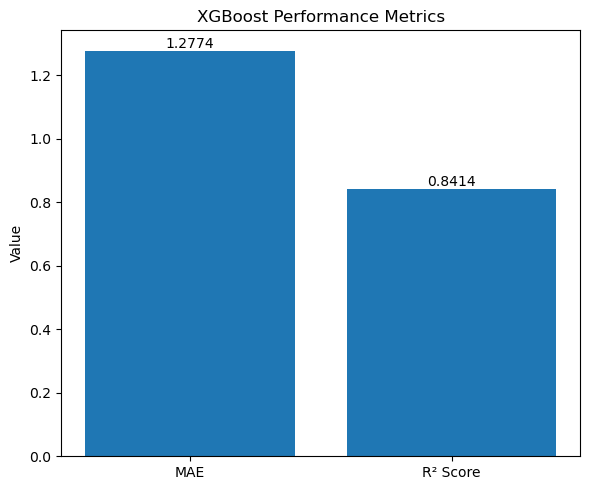

In [21]:
# 10. XGBOOST PERFORMANCE GRAPH
import matplotlib.pyplot as plt

# Metrics
metrics = ['MAE', 'R² Score']
values = [mae, r2]

plt.figure(figsize=(6, 5))
bars = plt.bar(metrics, values)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.4f}',
        ha='center',
        va='bottom'
    )

plt.title('XGBoost Performance Metrics')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

In [ ]:
11. SAVE TRAINED XGBOOST MODEL

In [22]:
import joblib

# Save model
joblib.dump(xgb_pipeline, "xgb_crop_yield_model.pkl")

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [23]:
import joblib

# Load model
loaded_model = joblib.load("xgb_crop_yield_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
# 5. MAKE PREDICTIONS

In [24]:
# Example prediction
y_pred = loaded_model.predict(X_test)

print(y_pred[:5])

[1.6456397  7.127819   1.231756   0.78677475 0.6944134 ]


In [ ]:
# Get indices of top 5 predicted yields


In [25]:
# Get top 5 highest predictions

top_indices = np.argsort(y_pred)[-5:][::-1]



print("Top 5 Highest Predicted Yields:\n")



for i in top_indices:

    print(f"Predicted Yield: {y_pred[i]:.2f}")

    print(f"Actual Yield:    {y_test.iloc[i]:.2f}")   # 👈 add this line

    print(X_test.iloc[i])

    print("-" * 40)  

Top 5 Highest Predicted Yields:

Predicted Yield: 55.45
Actual Yield:    59.60
state               UTTARAKHAND
district       UDAM SINGH NAGAR
crop                  Sugarcane
crop_year                  2005
season              Whole Year 
temperature           23.304615
rainfall              1101.7076
area                    27691.0
Name: 331842, dtype: object
----------------------------------------
Predicted Yield: 55.20
Actual Yield:    60.09
state          UTTAR PRADESH
district              AMROHA
crop               Sugarcane
crop_year               2003
season           Whole Year 
temperature        24.376923
rainfall           1154.5109
area                 73751.0
Name: 316700, dtype: object
----------------------------------------
Predicted Yield: 55.18
Actual Yield:    63.39
state          UTTAR PRADESH
district              AMROHA
crop               Sugarcane
crop_year               1998
season           Whole Year 
temperature        23.737692
rainfall           1090.8886
